# Breast Cancer Wisconsin Diagnostic Dataset 
- ➡️This is a classic dataset for training and benchmarking machine learning algorithms.
- ➡️ Biopsy features for classification of 569 malignant (cancer) and benign (not cancer) breast masses.
- ➡️ Features were computationally extracted from digital images of fine needle aspirate biopsy slides. Features correspond to properties of cell nuclei, such as size, shape and regularity. The mean, standard error, and worst value of each of 10 nuclear parameters is reported for a total of 30 features.
 
Available: https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset?resource=download 

### Details
- y. The outcomes. A factor with two levels denoting whether a mass is malignant ("M") or benign ("B").
- x. The predictors. A matrix with the mean, standard error and worst value of each of 10 nuclear measurements on the slide, for 30 total features per biopsy:
    - radius. Nucleus radius (mean of distances from center to points on perimeter).
    - texture. Nucleus texture (standard deviation of grayscale values).
    - perimeter. Nucleus perimeter.
    - area. Nucleus area.
    - smoothness. Nucleus smoothness (local variation in radius lengths).
    -  compactness. Nucleus compactness (perimeter^2/area - 1).
    - concavity, Nucleus concavity (severity of concave portions of the contour).
    - concave_pts. Number of concave portions of the nucleus contour.
    - symmetry. Nucleus symmetry.
    - fractal_dim. Nucleus fractal dimension ("coastline approximation" -1).

|Column	| Description|
|---------|-------------|
|x.radius_mean	|Mean radius of the tumor cells|
|x.radius_mean	|Mean radius of the tumor cells
|x.texture_mean	|Mean texture of the tumor cells
|x.perimeter_mean	|Mean perimeter of the tumor cells
|x.area_mean	|Mean area of the tumor cells
|x.smoothness_mean	|Mean smoothness of the tumor cells
|x.compactness_mean	|Mean compactness of the tumor cells
|x.concavity_mean	|Mean concavity of the tumor cells
|x.concave_points_mean	|Mean number of concave portions of the contour of the tumor cells
|x.symmetry_mean	|Mean symmetry of the tumor cells
|x.fractal_dimension_mean	|Mean "coastline approximation" of the tumor cells
|x.radius_se	|Standard error of the radius of the tumor cells
|x.texture_se	|Standard error of the texture of the tumor cells
|x.perimeter_se	|Standard error of the perimeter of the tumor cells
|x.area_se	|Standard error of the area of the tumor cells
|x.smoothness_se	|Standard error of the smoothness of the tumor cells
|x.compactness_se	|Standard error of the compactness of the tumor cells
|x.concavity_se	|Standard error of the concavity of the tumor cells
|x.concave_points_se	|Standard error of the number of concave portions of the contour of the tumor cells
|x.symmetry_se	|Standard error of the symmetry of the tumor cells
|x.fractal_dimension_se	|Standard error of the "coastline approximation" of the tumor cells
|x.radius_worst	|Worst (largest) radius of the tumor cells
|x.texture_worst	|Worst (most severe) texture of the tumor cells
|x.perimeter_worst	|Worst (largest) perimeter of the tumor cells
|x.area_worst	|Worst (largest) area of the tumor cells
|x.smoothness_worst	|Worst (most severe) smoothness of the tumor cells
|x.compactness_worst	|Worst (most severe) compactness of the tumor cells
|x.concavity_worst	|Worst (most severe) concavity of the tumor cells
|x.concave_points_worst	|Worst (most severe) number of concave portions of the contour of the tumor cells
|x.symmetry_worst	|Worst (most severe) symmetry of the tumor cells
|x.fractal_dimension_worst	|Worst (most severe) "coastline approximation" of the tumor cells
|y	target

In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


### 1. Load de dataset 

In [11]:
df = pd.read_csv('brca.csv')

### 2. Cleaning the data

In [12]:
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [ ]:
#1. There is a column called "Unnamed" that it is not needed, therefore, the column is deleted. 
df = df.drop('Unnamed: 0', axis=1)
df



,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,M
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115,M
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637,M
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820,M


In [ ]:
#2. Check for missing values
df.isnull().sum().sum()

np.int64(0)

In [14]:
#3. Convert the target (y) to numbers: M=Malignant -> 1 ; B=Bening -> 0. 
df['y'] = df['y'].map({'M': 1, 'B': 0})
df

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,0
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,0
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,0
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,0
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,1
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115,1
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637,1
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820,1


In [ ]:
#4. Delete the columns that it won't be used. I will only work with 'means'. 
cols_to_drop = [
    'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 
    'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 
    'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
    'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 
    'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 
    'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 
    'x.fractal_dim_worst'
]

df = df.drop(columns=cols_to_drop)

In [19]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,0
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,0
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,0
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,0
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,0


### 3. Exploratory Data Analysis (EDA)

In [ ]:
#1. Calculate the correlation only for the main "mean" columns. This shows which features are most related to the diagnosis (y).
main_features = ['y', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 
                 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean']

correlation_matrix = df[main_features].corr()

In [ ]:
#2. Standard Deviation and Skewness
stats_summary = df.groupby('y')[['x.radius_mean', 'x.area_mean', 'x.texture_mean']].agg(['mean', 'std', 'max'])
stats_summary

x.radius_mean                  x.area_mean                      \
           mean       std    max        mean         std     max   
y                                                                  
0     12.146524  1.780512  17.85  462.790196  134.287118   992.1   
1     17.462830  3.203971  28.11  978.376415  367.937978  2501.0   

  x.texture_mean                   
            mean       std    max  
y                                  
0      17.914762  3.995125  33.81  
1      21.604906  3.779470  39.28

### 4. Visualization

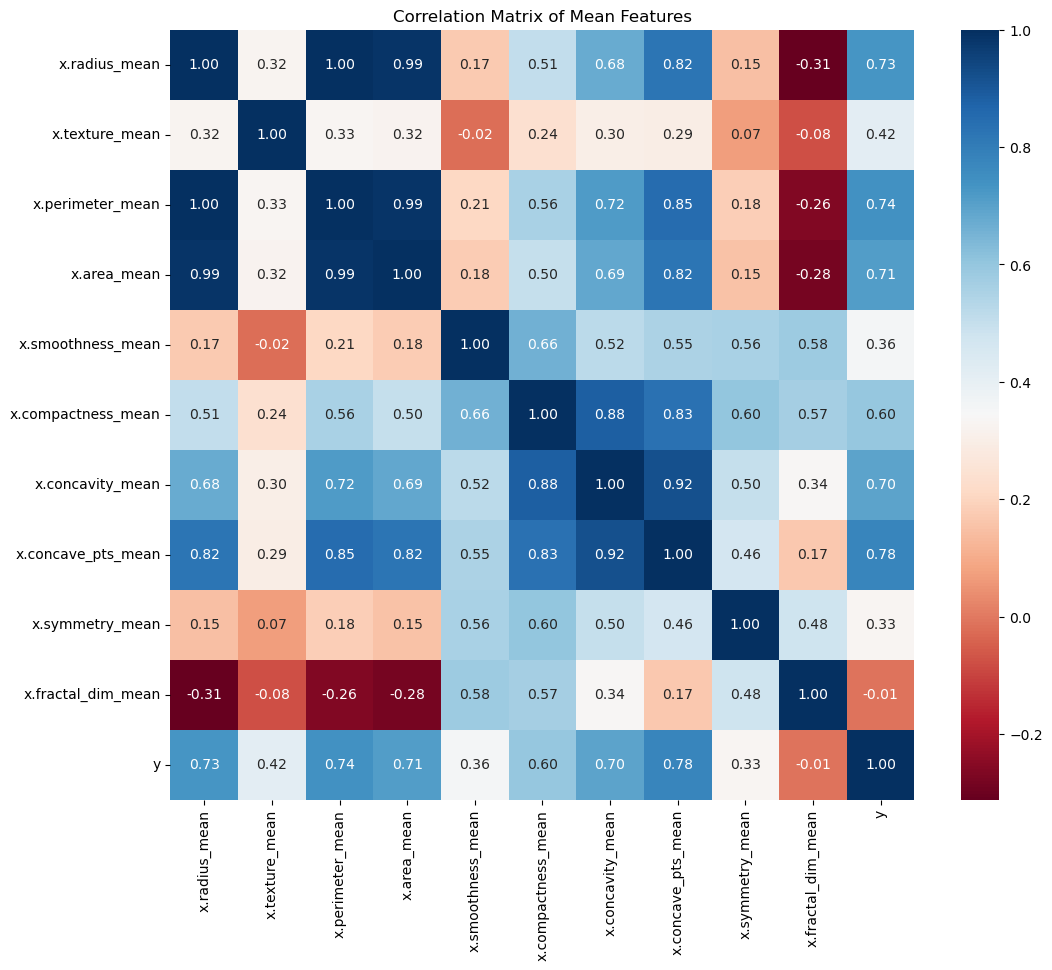

In [ ]:
#1. Create a Heatmap to visualize the correlations
plt.figure(figsize=(12, 10))
cor_matrix = df.corr()
sns.heatmap(cor_matrix, annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Matrix of Mean Features')
plt.show()

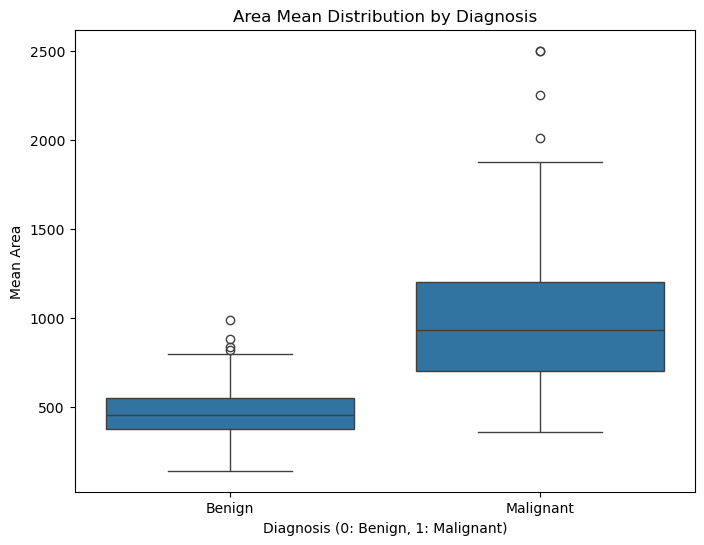

In [ ]:
#2. Create a Boxplot: here we can see outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='x.area_mean', data=df)
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Area Mean Distribution by Diagnosis')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
plt.ylabel('Mean Area')
plt.show()

C:\Users\lugon\AppData\Local\Temp\ipykernel_25792\1934858935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


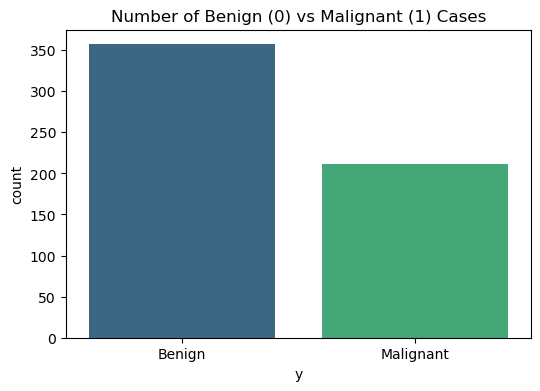

y
0    357
1    212
Name: count, dtype: int64

In [ ]:
#3.  Number of Benign (0) vs Malignant (1)

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Number of Benign (0) vs Malignant (1) Cases')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()

df['y'].value_counts()

In [40]:
diagnosis_names = {0: "Benign", 1: "Malignant"}
df_temp = df.copy()
df_temp['Diagnosis'] = df_temp['y'].map(diagnosis_names)

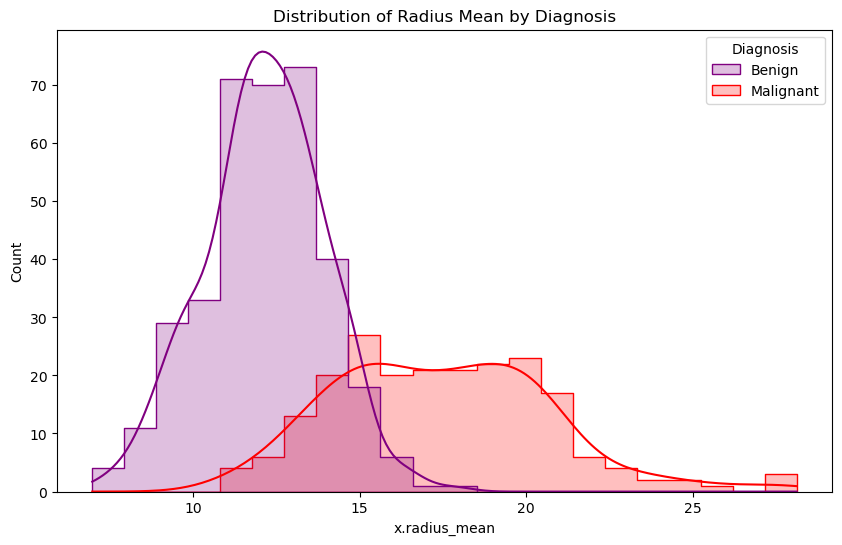

In [41]:
#4. Distribution of Radius Mean 

custom_colors = {"Benign": "purple", "Malignant": "red"}

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_temp, 
    x='x.radius_mean', 
    hue='Diagnosis', 
    kde=True, 
    element="step", 
    palette=custom_colors
)

plt.title('Distribution of Radius Mean by Diagnosis')
plt.show()

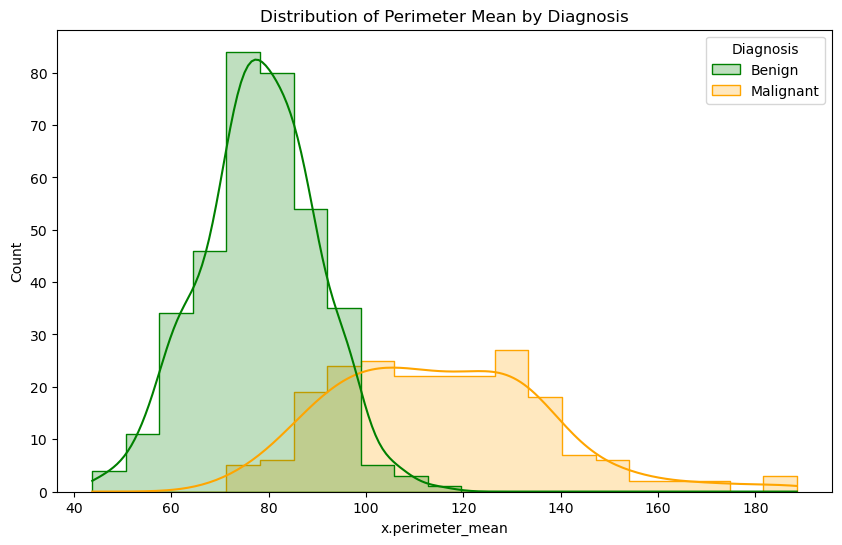

In [42]:
#5. Distribution of Perimeter Mean 
custom_colors2 = {"Benign": "green", "Malignant": "orange"}

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_temp, 
    x='x.perimeter_mean', 
    hue='Diagnosis', 
    kde=True, 
    element="step", 
    palette=custom_colors2
)

plt.title('Distribution of Perimeter Mean by Diagnosis')
plt.show()

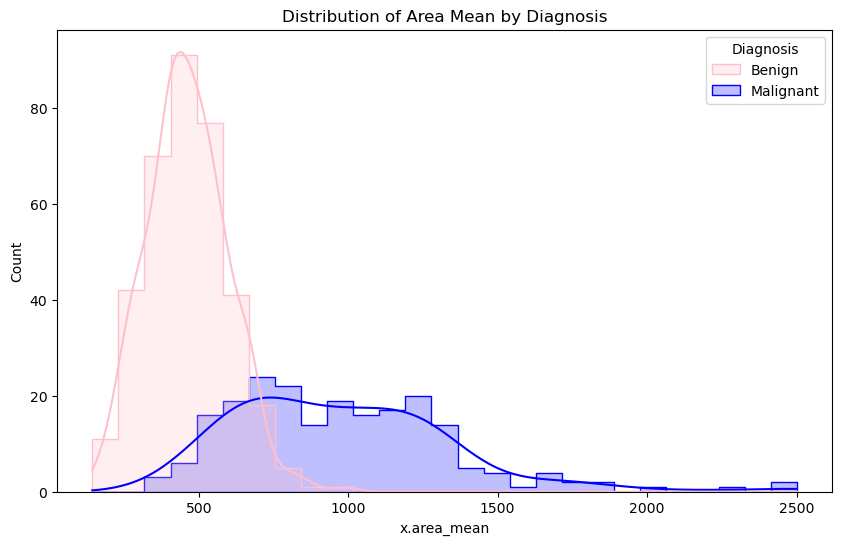

In [ ]:
#6. Distribution of Area Mean 
custom_colors = {"Benign": "pink", "Malignant": "blue"}

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_temp, 
    x='x.area_mean', 
    hue='Diagnosis', 
    kde=True, 
    element="step", 
    palette=custom_colors
)

plt.title('Distribution of Area Mean by Diagnosis')
plt.show()

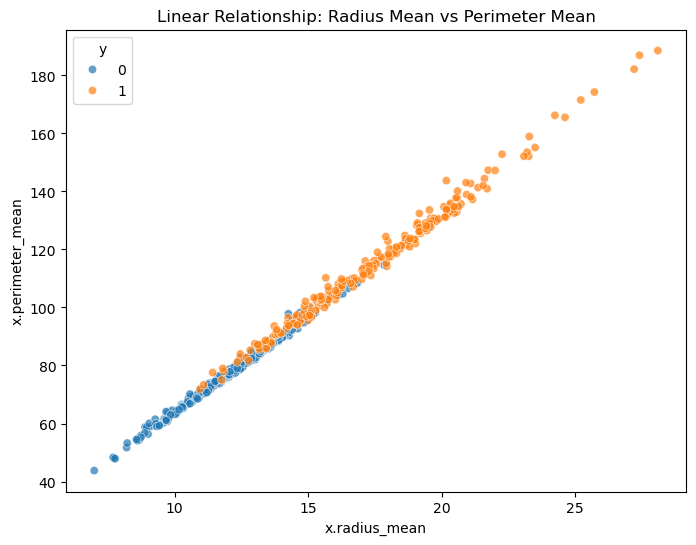

Correlation: 0.9979


In [ ]:
#7. Scatter plot to show the linear relationship between Radius and Perimeter
plt.figure(figsize=(8, 6))
sns.scatterplot(x='x.radius_mean', y='x.perimeter_mean', hue='y', data=df, alpha=0.7)
plt.title('Linear Relationship: Radius Mean vs Perimeter Mean')
plt.show()

print(f"Correlation: {df['x.radius_mean'].corr(df['x.perimeter_mean']):.4f}")

### 5. Machine Learning

In [ ]:
#1. Select only the three star features and the target
X = df[['x.radius_mean', 'x.perimeter_mean', 'x.area_mean']]
y = df['y']

In [53]:
# 2. The data is splitted: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In this step, the StandardScaler is used. It's a way to put all our numbers in the same range.

If we look at the data, x.area_mean has very big numbers (like 1000) while x.radius_mean has small numbers (like 10). Without scaling, a model like KNN would think the area is much more important just because the numbers are bigger. By scaling them, we make sure the model treats all features equally.

Also, it's important to notice that we only "teach" the scaler with the training data (fit_transform). For the test data, we just apply the change (transform). We do this to avoid "cheating," ensuring the model doesn't see any information from the test set before the final exam.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [56]:
X_train.head()

,x.radius_mean,x.perimeter_mean,x.area_mean
68,8.219,53.27,203.9
181,12.990,84.08,514.3
63,11.900,78.11,432.8
248,10.030,63.19,307.3
60,11.430,73.66,398.0


In [63]:
y_train.head()

68     0
181    0
63     0
248    0
60     0
Name: y, dtype: int64

In [ ]:
#4. Linear Regresion to predict the `perimeter_mean` based on the `radius_mean`.


X_reg = df[['x.radius_mean']] 
y_reg = df['x.perimeter_mean']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg)

# 5. Evaluate the model
print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, y_pred_reg):.4f}")


R2 Score: 0.9952
Mean Squared Error: 2.8574


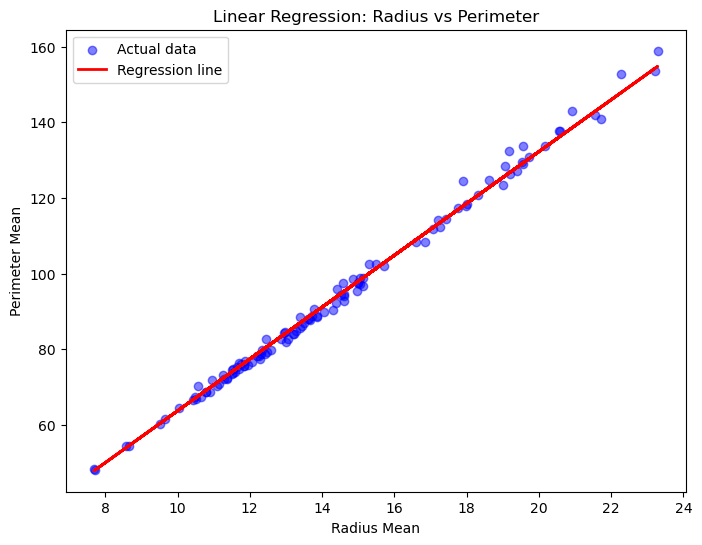

In [66]:
#5. Visualization of the Regression Line
plt.figure(figsize=(8, 6))

# Plot the real data points from the test set
plt.scatter(X_test_reg, y_test_reg, color='blue', alpha=0.5, label='Actual data')

# Plot the prediction line
plt.plot(X_test_reg, y_pred_reg, color='red', linewidth=2, label='Regression line')

plt.title('Linear Regression: Radius vs Perimeter')
plt.xlabel('Radius Mean')
plt.ylabel('Perimeter Mean')
plt.legend()
plt.show()

In these steps, I wanted to see how well one variable can predict another. I chose Radius and Perimeter because they are closely related.

The model got an R2 Score of almost 1.0 (which is a perfect score!). This means my model is very accurate. In the graph, the red line goes exactly through the middle of the points, showing that if we know the radius of a cell, we can easily calculate its perimeter using this linear model.

In [ ]:
#6. Training the KNN Module 


# 1. Initialize the model
# We choose 5 neighbors for the first try
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model using the SCALED data
knn.fit(X_train_scaled, y_train)

# 3. Predict the results for the test set
y_pred_knn = knn.predict(X_test_scaled)

# 4. Check the Accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy:.4f}")


KNN Accuracy: 0.9035


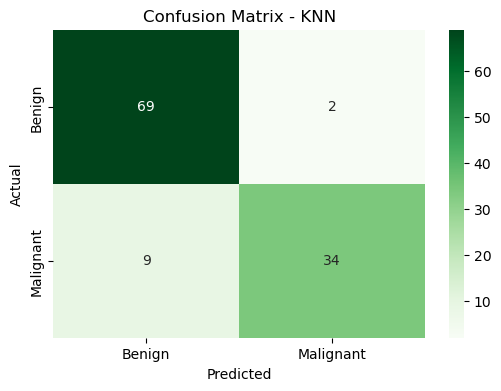


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93        71
           1       0.94      0.79      0.86        43

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114



In [68]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plotting the confusion matrix for the presentation
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))